# Assignment 02: My Affective Milan

## A psychogeography of everyday life

After living in a city for a long time, we gradually stop recognizing it only through its official monuments and tourist attractions. The lived city takes on a different form: the true monuments of everyday life become favorite places, friends' homes, bars, parks, places of study and work, and routes repeated over time.

This notebook constructs a personal psychogeography of Milan and relates it to the official metro network. It follows the workflow introduced in the course geoprocessing tutorials: importing spatial data, checking coordinate reference systems, reprojecting, performing a nearest spatial join, calculating distances, classifying results, and mapping them.

## Goals

This notebook will:

- load a personal GeoJSON of affective places in Milan;
- load official NIL neighborhood boundaries and ATM metro data;
- protect residential privacy by using only generalized home locations;
- find the nearest metro station to each favorite place;
- classify places using a 500-meter walking-distance threshold;
- create two maps: **Everyday Monuments** and **Relationship with the Metro**;
- export an analyzed GeoJSON containing the geoprocessing results.

## Import libraries

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D
from shapely.geometry import LineString

plt.rcParams["figure.figsize"] = (11, 11)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"

## Define local paths

All inputs are stored inside the assignment directory so the notebook can be run without downloading data from the internet. The Municipality of Milan datasets were downloaded from its Open Data portal.

In [2]:
DATA_DIR = Path("02-Data")
MAP_DIR = Path("02-Maps")
MAP_DIR.mkdir(exist_ok=True)

personal_path = DATA_DIR / "michelle-milano-affettiva.geojson"
nil_path = DATA_DIR / "milano-nil.geojson"
stations_path = DATA_DIR / "atm-metro-fermate.geojson"
routes_path = DATA_DIR / "atm-metro-percorsi.geojson"

## Import datasets

In [3]:
personal = gpd.read_file(personal_path)
nil = gpd.read_file(nil_path)
stations = gpd.read_file(stations_path)
routes = gpd.read_file(routes_path)

pd.DataFrame(
    {
        "dataset": ["Personal places", "NIL neighborhoods", "Metro stations", "Metro routes"],
        "features": [len(personal), len(nil), len(stations), len(routes)],
        "geometry": [
            ", ".join(personal.geom_type.unique()),
            ", ".join(nil.geom_type.unique()),
            ", ".join(stations.geom_type.unique()),
            ", ".join(routes.geom_type.unique()),
        ],
        "crs": [str(personal.crs), str(nil.crs), str(stations.crs), str(routes.crs)],
    }
)

,dataset,features,geometry,crs
0,Personal places,35,"Point, LineString",EPSG:4326
1,NIL neighborhoods,88,Polygon,EPSG:4326
2,Metro stations,130,Point,EPSG:4326
3,Metro routes,31,LineString,EPSG:4326


The personal file contains both points and schematic metro lines. We separate its geometries and categories before beginning the analysis. Residential points remain in the visualization but are excluded from distance statistics because their coordinates were deliberately generalized for privacy.

In [4]:
personal_points = personal[personal.geom_type == "Point"].copy()
preferred_routes = personal[personal.geom_type == "LineString"].copy()

home = personal_points[personal_points["category"] == "casa_riferimento"].copy()
friends = personal_points[personal_points["category"] == "casa_amici"].copy()
favorite_places = personal_points[
    personal_points["category"] == "posto_del_cuore"
].copy()

pd.Series(
    {
        "relational origin": len(home),
        "friends' homes": len(friends),
        "favorite places": len(favorite_places),
        "preferred metro routes": len(preferred_routes),
    },
    name="feature count",
)

relational origin          1
friends' homes             5
favorite places           27
preferred metro routes     2
Name: feature count, dtype: int64

## Inspect the source geography

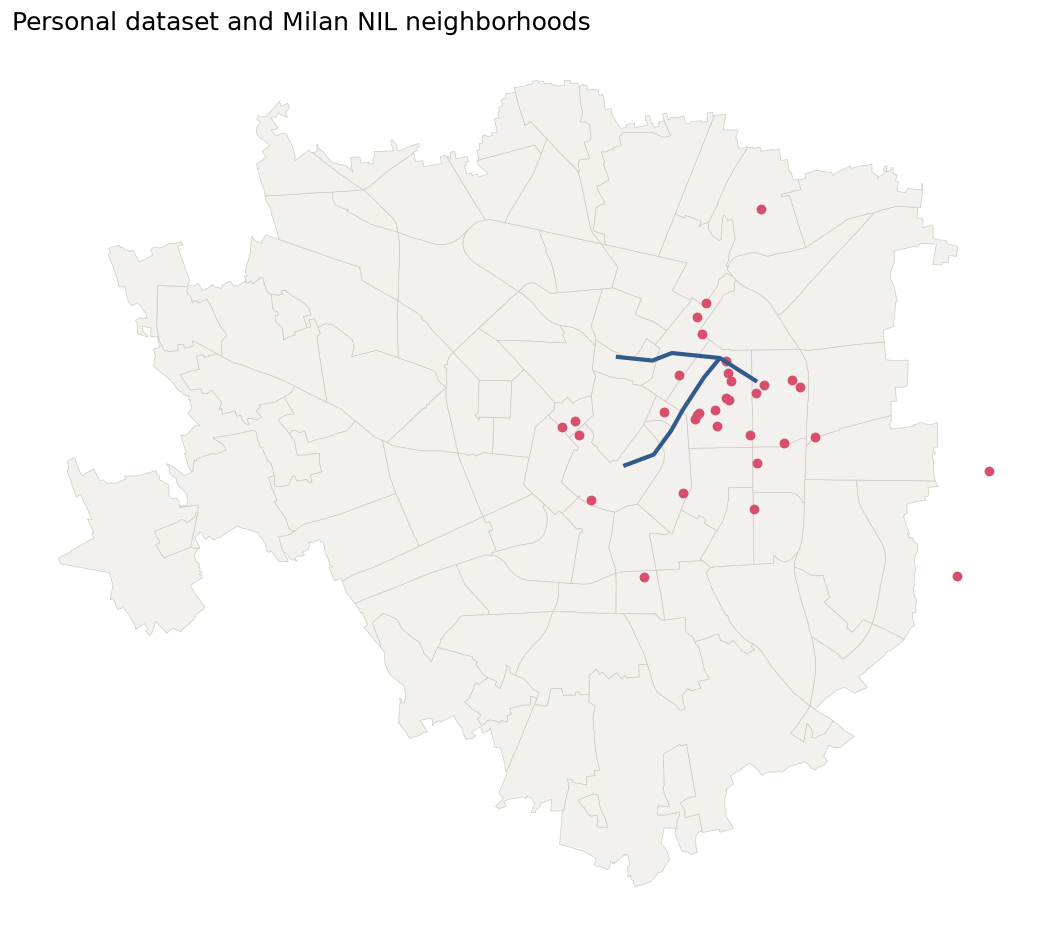

In [5]:
ax = nil.plot(color="#f3f1ed", edgecolor="#c8c4bc", linewidth=0.35)
personal_points.plot(ax=ax, color="#d64f6c", markersize=24)
preferred_routes.plot(ax=ax, color="#315b8a", linewidth=2.5)
ax.set_title("Personal dataset and Milan NIL neighborhoods", loc="left", fontsize=15)
ax.set_axis_off()
plt.show()

## Align coordinate reference systems

The source data use WGS 84 geographic coordinates. Longitude and latitude are suitable for storage and web mapping, but degrees are not appropriate units for measuring local distance. Following the course tutorial, all layers are reprojected to a projected CRS before geoprocessing.

For Milan, **EPSG:32632 (WGS 84 / UTM zone 32N)** provides coordinates in meters.

In [6]:
METRIC_CRS = "EPSG:32632"

personal_m = personal.to_crs(METRIC_CRS)
personal_points_m = personal_points.to_crs(METRIC_CRS)
preferred_routes_m = preferred_routes.to_crs(METRIC_CRS)
home_m = home.to_crs(METRIC_CRS)
friends_m = friends.to_crs(METRIC_CRS)
favorite_places_m = favorite_places.to_crs(METRIC_CRS)
nil_m = nil.to_crs(METRIC_CRS)
stations_m = stations.to_crs(METRIC_CRS)
routes_m = routes.to_crs(METRIC_CRS)

# Calculate each favorite place's distance from the anonymized home location.
origin = home_m.geometry.iloc[0]
favorite_places_m["distance_from_home_m"] = (
    favorite_places_m.geometry.distance(origin).round(1)
)

favorite_places_m.crs

<Projected CRS: EPSG:32632>
Name: WGS 84 / UTM zone 32N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 6°E and 12°E, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Austria. Cameroon. Denmark. Equatorial Guinea. France. Gabon. Germany. Italy. Libya. Liechtenstein. Monaco. Netherlands. Niger. Nigeria. Norway. Sao Tome and Principe. Svalbard. Sweden. Switzerland. Tunisia. Vatican City State.
- bounds: (6.0, 0.0, 12.0, 84.0)
Coordinate Operation:
- name: UTM zone 32N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

## Find the nearest metro station

GeoPandas' `sjoin_nearest()` associates each favorite place with the nearest ATM station. The `distance_col` argument records the distance in the units of the projected CRS—meters in this case.

In [7]:
places_nearest = favorite_places_m.sjoin_nearest(
    stations_m[["nome", "linee", "geometry"]],
    how="left",
    distance_col="distance_m",
)

# In the rare case of an equal-distance tie, retain one station per place.
places_nearest = (
    places_nearest.reset_index(names="source_index")
    .sort_values(["source_index", "distance_m"])
    .drop_duplicates("source_index")
    .set_index("source_index")
)

places_nearest = places_nearest.rename(
    columns={"nome": "nearest_station", "linee": "metro_lines"}
)
places_nearest["distance_m"] = places_nearest["distance_m"].round(1)
places_nearest["within_500m"] = places_nearest["distance_m"] <= 500

places_nearest[
    ["name", "nearest_station", "metro_lines", "distance_m", "within_500m"]
].sort_values("distance_m").head(10)

,name,nearest_station,metro_lines,distance_m,within_500m
source_index,,,,,
31,Pizzeria Santa Maria,PRECOTTO,1,128.9,True
22,Colonne di San Lorenzo,VETRA,4,157.6,True
13,Politecnico — Patio,PIOLA,2,192.8,True
27,Castello Sforzesco,CADORNA FN M2,2,250.6,True
6,Bar Picchio,P.TA VENEZIA,1,297.2,True
21,Égalité,P.TA VENEZIA,1,331.5,True
20,Piazza Leonardo da Vinci,PIOLA,2,344.8,True
29,Via Mauro Macchi 6,CENTRALE FS,"2,3",360.5,True
32,Piccola Ischia,LORETO M2,2,361.0,True


## Summarize the results

In [8]:
summary = pd.Series(
    {
        "favorite places": len(places_nearest),
        "within 500 m": int(places_nearest["within_500m"].sum()),
        "beyond 500 m": int((~places_nearest["within_500m"]).sum()),
        "median distance (m)": round(places_nearest["distance_m"].median()),
        "minimum distance (m)": round(places_nearest["distance_m"].min()),
        "maximum distance (m)": round(places_nearest["distance_m"].max()),
    },
    name="result",
)
summary.to_frame()

,result
favorite places,27
within 500 m,15
beyond 500 m,12
median distance (m),444
minimum distance (m),129
maximum distance (m),2071


## Map 1: Everyday Monuments

This map replaces Milan's official tourist hierarchy with a personal one. The generalized home point functions as the relational origin. Color expresses the metric distance between home and each favorite place: pink identifies the closest places, followed by purple, turquoise, green, and yellow as distance increases. The connecting lines visualize the mental relationship between the origin and places where memories have accumulated.

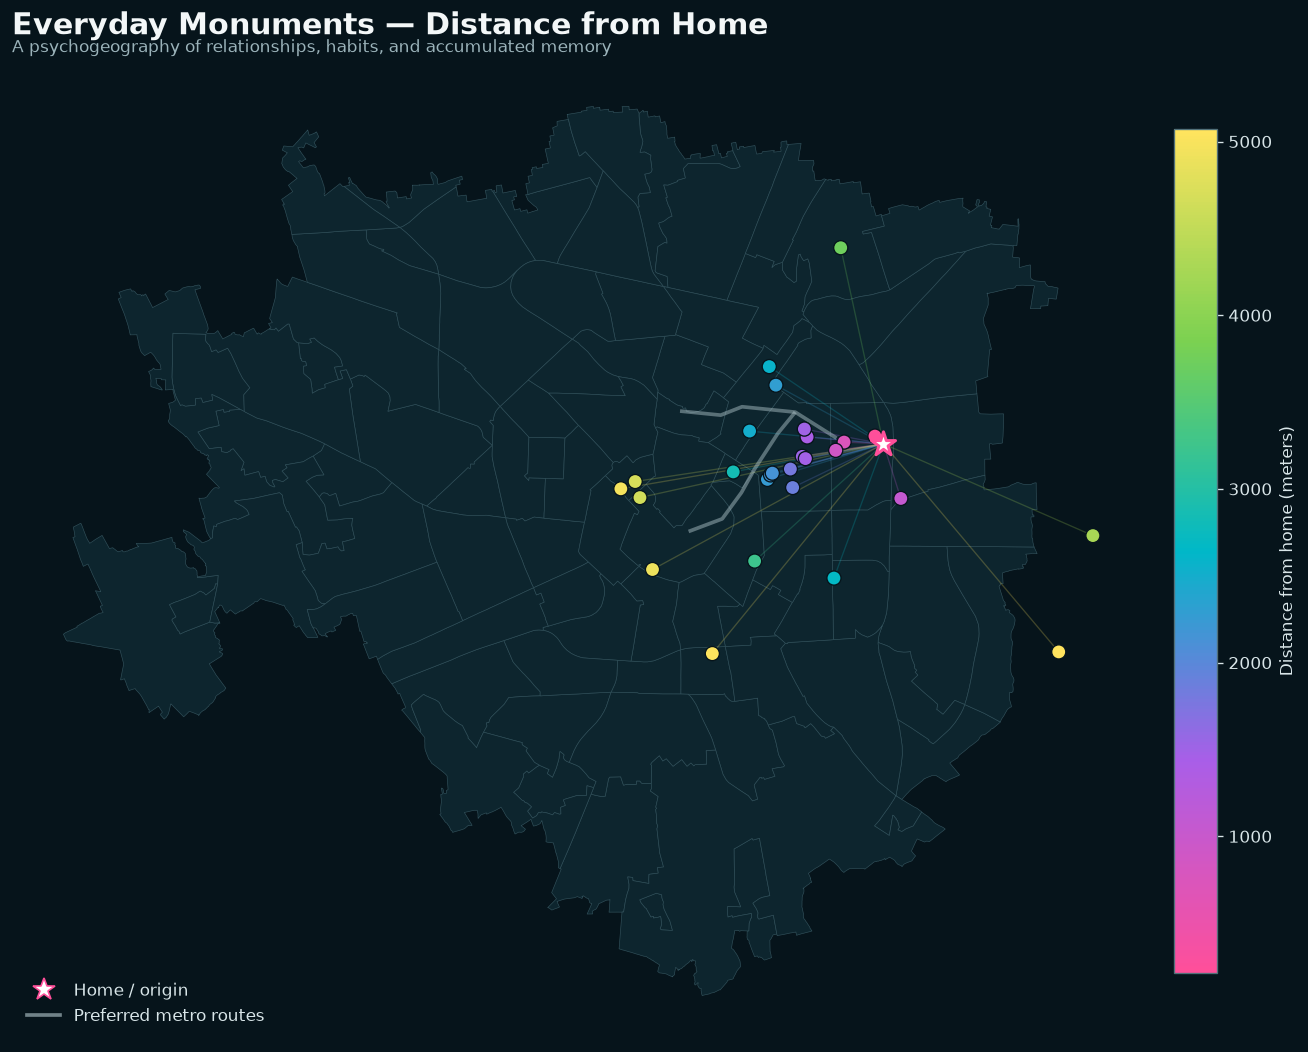

In [9]:
memory_lines = gpd.GeoDataFrame(
    {
        "name": favorite_places_m["name"].values,
        "distance_from_home_m": favorite_places_m["distance_from_home_m"].values,
    },
    geometry=[LineString([origin, point]) for point in favorite_places_m.geometry],
    crs=METRIC_CRS,
)

distance_cmap = LinearSegmentedColormap.from_list(
    "affective_distance",
    ["#ff4f9a", "#a95ee8", "#00b8c8", "#7bd151", "#ffe45e"],
)
distance_norm = Normalize(
    vmin=favorite_places_m["distance_from_home_m"].min(),
    vmax=favorite_places_m["distance_from_home_m"].max(),
)

fig, ax = plt.subplots(figsize=(11, 11), facecolor="#06141b")
ax.set_facecolor("#06141b")
nil_m.plot(ax=ax, color="#0d252e", edgecolor="#31505a", linewidth=0.38)

# Each connection inherits the color of its destination's distance from home.
for _, connection in memory_lines.iterrows():
    gpd.GeoSeries([connection.geometry], crs=METRIC_CRS).plot(
        ax=ax,
        color=distance_cmap(distance_norm(connection["distance_from_home_m"])),
        alpha=0.23,
        linewidth=0.8,
    )

preferred_routes_m.plot(
    ax=ax, color="#b8ccd2", linewidth=2.2, alpha=0.45, zorder=3
)

favorite_places_m.plot(
    ax=ax,
    column="distance_from_home_m",
    cmap=distance_cmap,
    norm=distance_norm,
    edgecolor="#06141b",
    linewidth=0.8,
    markersize=72,
    zorder=5,
)
home_m.plot(
    ax=ax,
    color="#ffffff",
    edgecolor="#ff4f9a",
    marker="*",
    linewidth=1.8,
    markersize=230,
    zorder=7,
)

scalar_map = plt.cm.ScalarMappable(norm=distance_norm, cmap=distance_cmap)
colorbar = fig.colorbar(scalar_map, ax=ax, fraction=0.035, pad=0.025)
colorbar.set_label("Distance from home (meters)", color="#d8e5e8")
colorbar.ax.tick_params(colors="#d8e5e8")
colorbar.outline.set_edgecolor("#52717a")

legend = [
    Line2D([0], [0], marker="*", color="none", markerfacecolor="white", markeredgecolor="#ff4f9a", markersize=14, label="Home / origin"),
    Line2D([0], [0], color="#b8ccd2", alpha=0.6, linewidth=2.2, label="Preferred metro routes"),
]
legend_artist = ax.legend(handles=legend, loc="lower left", frameon=False)
for text in legend_artist.get_texts():
    text.set_color("#d8e5e8")

ax.set_title(
    "Everyday Monuments — Distance from Home",
    loc="left",
    fontsize=18,
    fontweight="bold",
    color="#f3f7f8",
)
ax.text(
    0,
    1.01,
    "A psychogeography of relationships, habits, and accumulated memory",
    transform=ax.transAxes,
    fontsize=10,
    color="#9bb3ba",
)
ax.set_axis_off()
fig.tight_layout()
fig.savefig(MAP_DIR / "milano-monumenti-quotidiani-python.png", dpi=220, bbox_inches="tight")
plt.show()

## Map 2: Relationship with the Metro

The second map uses the official ATM network. Favorite places are classified according to whether their nearest station is within a 500-meter walking-distance threshold.

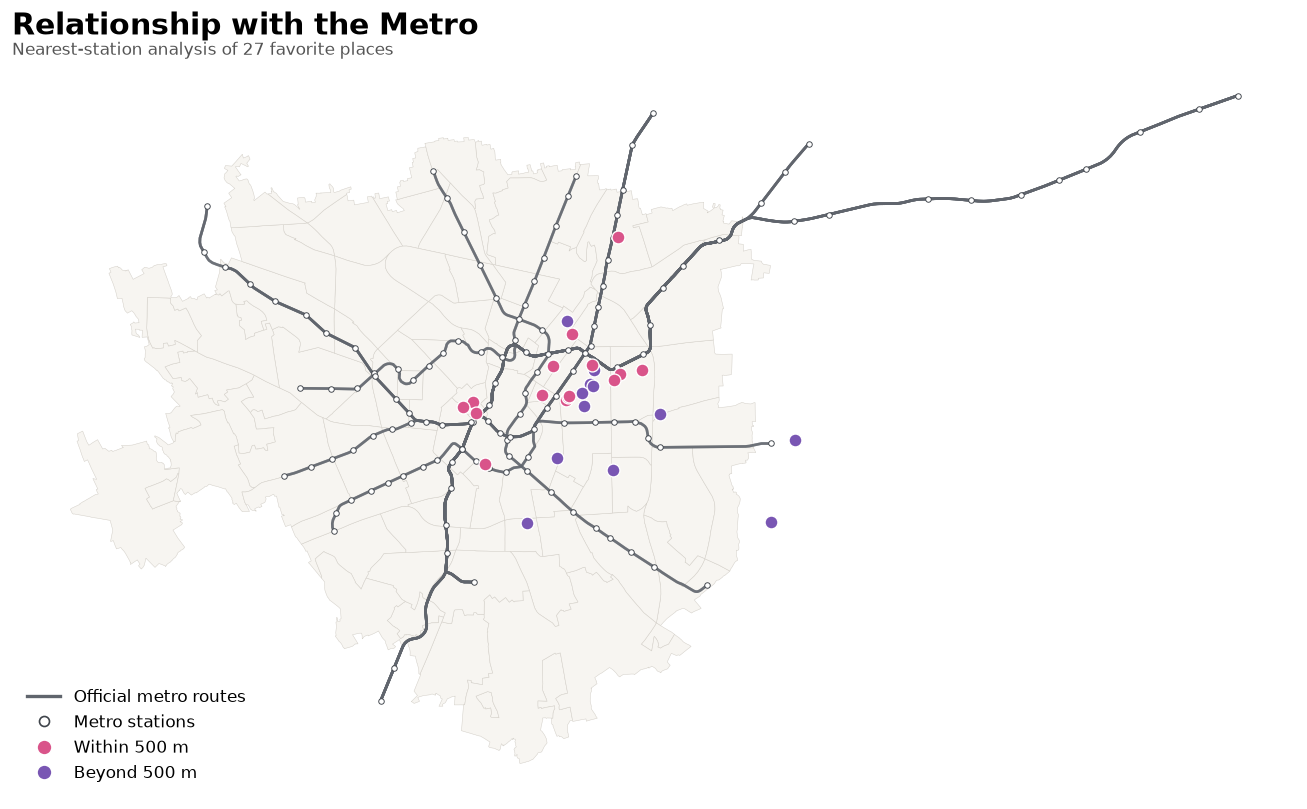

In [10]:
fig, ax = plt.subplots(figsize=(11, 11))
nil_m.plot(ax=ax, color="#f7f5f1", edgecolor="#d4d0c9", linewidth=0.3)
routes_m.plot(ax=ax, color="#60656d", linewidth=1.6, alpha=0.70)
stations_m.plot(
    ax=ax,
    facecolor="white",
    edgecolor="#3f444b",
    linewidth=0.55,
    markersize=11,
    zorder=3,
)

places_nearest[~places_nearest["within_500m"]].plot(
    ax=ax,
    color="#7956b3",
    edgecolor="white",
    linewidth=0.8,
    markersize=60,
    zorder=4,
)
places_nearest[places_nearest["within_500m"]].plot(
    ax=ax,
    color="#d9548a",
    edgecolor="white",
    linewidth=0.8,
    markersize=60,
    zorder=5,
)

legend = [
    Line2D([0], [0], color="#60656d", linewidth=2, label="Official metro routes"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="white", markeredgecolor="#3f444b", markersize=6, label="Metro stations"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#d9548a", markeredgecolor="white", markersize=9, label="Within 500 m"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#7956b3", markeredgecolor="white", markersize=9, label="Beyond 500 m"),
]
ax.legend(handles=legend, loc="lower left", frameon=False)
ax.set_title("Relationship with the Metro", loc="left", fontsize=18, fontweight="bold")
ax.text(
    0,
    1.01,
    "Nearest-station analysis of 27 favorite places",
    transform=ax.transAxes,
    fontsize=10,
    color="#555555",
)
ax.set_axis_off()
fig.tight_layout()
fig.savefig(MAP_DIR / "milano-relazione-metro-python.png", dpi=220, bbox_inches="tight")
plt.show()

## Export the analyzed dataset

In [11]:
places_output = places_nearest.to_crs("EPSG:4326").copy()
places_output[
    [
        "name",
        "category",
        "subcategory",
        "distance_from_home_m",
        "nearest_station",
        "metro_lines",
        "distance_m",
        "within_500m",
        "geometry",
    ]
].to_file(
    DATA_DIR / "michelle-milano-affettiva-analyzed.geojson",
    driver="GeoJSON",
)

DATA_DIR / "michelle-milano-affettiva-analyzed.geojson"

WindowsPath('02-Data/michelle-milano-affettiva-analyzed.geojson')

## Interpretation

The analysis reveals the central role of the Città Studi–Porta Venezia–city center axis in my experience of Milan. More than half of the favorite places are within a short walk of the metro. Accessibility can encourage repeated visits, and repetition contributes to the construction of memory.

Places beyond the 500-meter threshold are not less important. They can instead be understood as intentional destinations: places visited because they have a particular personal value, rather than simply because they are easy to reach. The resulting psychogeography combines two relationships—the familiarity produced by proximity and repetition, and the affection that justifies a longer journey.

The final maps can therefore be read as a spatial self-portrait. They do not show what Milan officially considers important, but what has become important through my way of inhabiting the city.

## Data sources and limitations

- Personal dataset: created for this assignment from a list of meaningful places.
- NIL boundaries: Municipality of Milan, *Local Identity Units (NIL) — PGT 2030*.
- Metro stations and routes: Municipality of Milan / ATM Open Data.
- Residential locations are deliberately generalized and must not be interpreted as exact addresses.
- The personal M1 and M2 lines are schematic; the distance analysis uses official ATM station geometries.
- The location of Pizzeria Santa Maria requires personal confirmation.